In [3]:
import pandas as pd
import duckdb


In [4]:
customers = pd.read_csv(r"C:\Users\admin\Downloads\retail_banking_customers.csv")
transactions = pd.read_csv(r"C:\Users\admin\Downloads\retail_banking_transactions.csv")

In [5]:
customers.head()
transactions.head()

,customer_id,month,monthly_transactions
0,CUST102702,2022-01,11
1,CUST102702,2022-02,11
2,CUST102702,2022-03,17
3,CUST102702,2022-04,15
4,CUST102702,2022-05,16


In [7]:
customers.info()
customers.describe()
transactions.info()
transactions.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               5000 non-null   object 
 1   age                       5000 non-null   int64  
 2   region                    5000 non-null   object 
 3   preferred_channel         5000 non-null   object 
 4   monthly_transactions_avg  5000 non-null   int64  
 5   avg_monthly_balance       5000 non-null   int64  
 6   num_products_held         5000 non-null   int64  
 7   digital_adoption_score    5000 non-null   float64
 8   credit_card_issued        5000 non-null   int64  
 9   loan_taken                5000 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 390.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------

,monthly_transactions
count,24000.000000
mean,20.099458
std,6.899025
min,0.000000
25%,15.000000
50%,20.000000
75%,25.000000
max,39.000000


In [8]:
#Handle Missing Values
customers.isnull().sum()

transactions.isnull().sum()

customer_id             0
month                   0
monthly_transactions    0
dtype: int64

In [9]:
#Check Duplicate Records
customers.duplicated().sum()

transactions.duplicated().sum()

np.int64(0)

In [12]:
con=duckdb.connect()

In [13]:
con.register("customers",customers)
con.register("transactions",transactions)

In [14]:
query="""
SELECT * FROM customers
LIMIT 5
"""
result=con.execute(query).df()
result

,customer_id,age,region,preferred_channel,monthly_transactions_avg,avg_monthly_balance,num_products_held,digital_adoption_score,credit_card_issued,loan_taken
0,CUST100000,56,North,ATM,29,36460,1,0.56,0,0
1,CUST100001,69,South,Branch,15,54595,3,0.74,1,0
2,CUST100002,46,West,Online Banking,12,55180,3,0.08,0,0
3,CUST100003,32,North,Branch,23,50150,2,0.52,0,0
4,CUST100004,60,Central,Online Banking,18,61720,2,0.62,1,0


In [15]:
#Merge Both Datasets
query = """
SELECT
    t.customer_id,
    t.month,
    t.monthly_transactions,
    c.preferred_channel,
    c.age,
    c.region,
    c.avg_monthly_balance,
    c.preferred_channel,
    c.digital_adoption_score,
FROM transactions t
LEFT JOIN customers c
ON t.customer_id = c.customer_id
"""

merged_df = con.execute(query).df()

merged_df.head()

,customer_id,month,monthly_transactions,preferred_channel,age,region,avg_monthly_balance,preferred_channel_1,digital_adoption_score
0,CUST102702,2022-01-01,11,ATM,62,North,23130,ATM,0.05
1,CUST102702,2022-02-01,11,ATM,62,North,23130,ATM,0.05
2,CUST102702,2022-03-01,17,ATM,62,North,23130,ATM,0.05
3,CUST102702,2022-04-01,15,ATM,62,North,23130,ATM,0.05
4,CUST102702,2022-05-01,16,ATM,62,North,23130,ATM,0.05


In [17]:
merged_df.to_csv(
    r"C:\Users\admin\Downloads\Retail_Banking_Project\merged_retail_banking.csv",
    index=False
)

In [18]:
#Convert Data Types
transactions["month"] = pd.to_datetime(transactions["month"])

In [21]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           24000 non-null  object        
 1   month                 24000 non-null  datetime64[ns]
 2   monthly_transactions  24000 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 562.6+ KB


Day 2 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
customers = pd.read_csv(r"C:\Users\admin\Downloads\retail_banking_customers.csv")
transactions = pd.read_csv(r"C:\Users\admin\Downloads\retail_banking_transactions.csv")

In [5]:
transactions["month"] = pd.to_datetime(transactions["month"])

Feature Engineering

In [7]:
customers["Age_group"]=pd.cut(customers["age"],
                              bins=[18,30,45,60,100],
                              labels=["18-30","31-45","46-60","60+"]
                             )
                              

In [11]:
customers["Balance_Category"]=pd.cut(customers["avg_monthly_balance"],
                                     bins=[0,30000,60000,100000],
                                     labels=["Low","Medium","High"]
                                     )

In [13]:
transactions["Month_Name"]=transactions["month"].dt.month_name()

In [ ]:
EDA Process

Which region has the highest average balance?

In [15]:
customers.groupby("region")["avg_monthly_balance"].sum()

region
Central    50267129
East       47621097
North      49274952
South      53955283
West       49637509
Name: avg_monthly_balance, dtype: int64

Which age group performs the most transactions?

In [18]:
merged = customers.merge(transactions, on="customer_id")

In [20]:
merged.groupby("Age_group")["monthly_transactions"].mean()

C:\Users\admin\AppData\Local\Temp\ipykernel_18876\2057473555.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby("Age_group")["monthly_transactions"].mean()


Age_group
18-30    21.091270
31-45    19.956336
46-60    19.806964
60+      19.698947
Name: monthly_transactions, dtype: float64

Which banking channel is most popular?

In [21]:
customers["preferred_channel"].value_counts()

preferred_channel
Branch            1303
Online Banking    1263
ATM               1234
Mobile App        1200
Name: count, dtype: int64

In [22]:
merged.groupby("digital_adoption_score")["monthly_transactions"].mean()

digital_adoption_score
0.00    20.208333
0.01    17.880208
0.02    22.425000
0.03    20.475694
0.04    19.354167
          ...    
0.96    14.888889
0.97    13.281250
0.98    22.888889
0.99    22.955128
1.00    27.729167
Name: monthly_transactions, Length: 101, dtype: float64

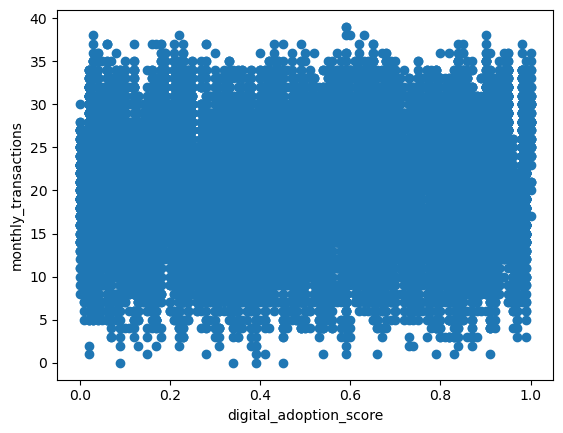

In [28]:
plt.scatter(
    merged["digital_adoption_score"],
    merged["monthly_transactions"]
)
plt.xlabel("digital_adoption_score")
plt.ylabel("monthly_transactions")
plt.show()


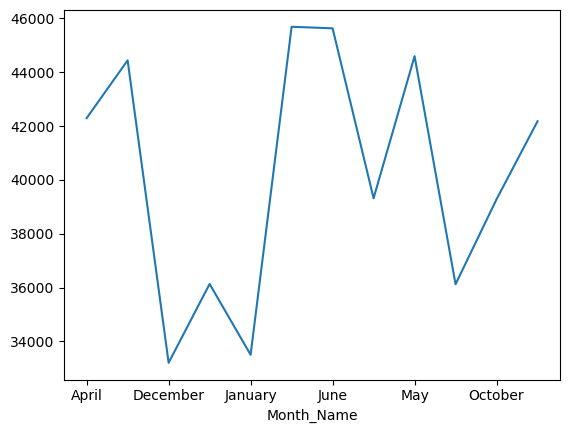

In [31]:
transactions.groupby("Month_Name")["monthly_transactions"].sum().plot(kind="line")
plt.show()

In [37]:
merged_df = pd.merge(
    customers,
    transactions,
    on="customer_id",
    how="inner"
)

In [39]:
merged_df.to_csv(
    r"C:\Users\admin\Downloads\Retail_Banking_Project\merged_retail_banking.csv",
    index=False
)

Unvariate Analysis

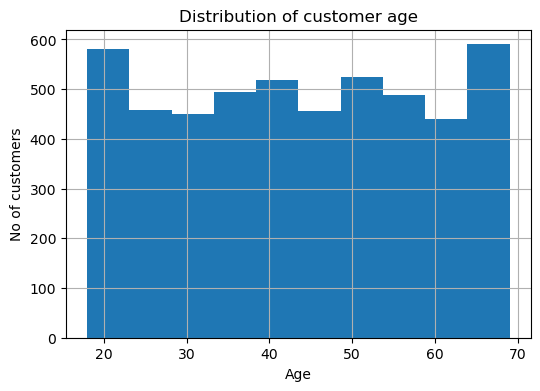

In [41]:
plt.figure(figsize=(6,4))
customers["age"].hist(bins=10)

plt.title("Distribution of customer age")
plt.xlabel("Age")
plt.ylabel("No of customers")
plt.show()


In [ ]:
Ans:The majority of customers belong to the 30-45 age group.

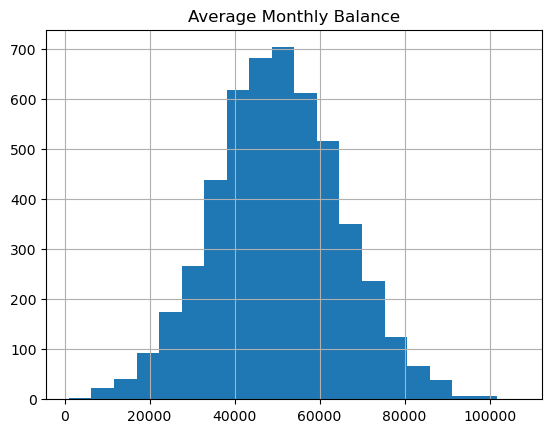

In [57]:
customers["avg_monthly_balance"].hist(bins=20)
plt.title("Average Monthly Balance")
plt.show()

In [ ]:
Ans:Avg monthly balances are right-skewed, with a small number of high-value customers.

Category-wise Comparisons

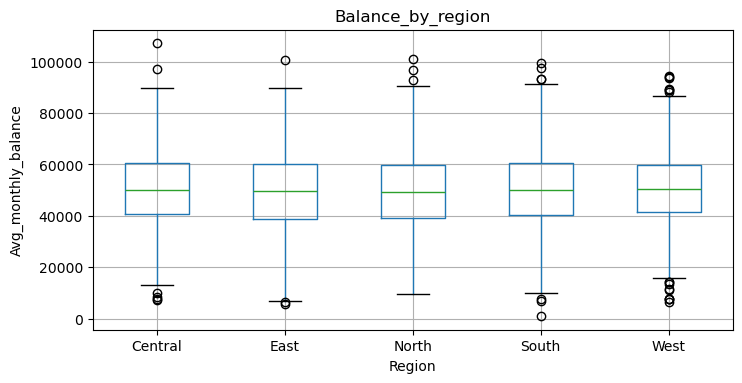

In [49]:
import matplotlib.pyplot as plt

customers.boxplot(column="avg_monthly_balance",by="region",figsize=(8,4))
plt.title("Balance_by_region")
plt.suptitle("")
plt.xlabel("Region")
plt.ylabel("Avg_monthly_balance")
plt.show()

In [ ]:
Ans: West region has the highest median account balance.

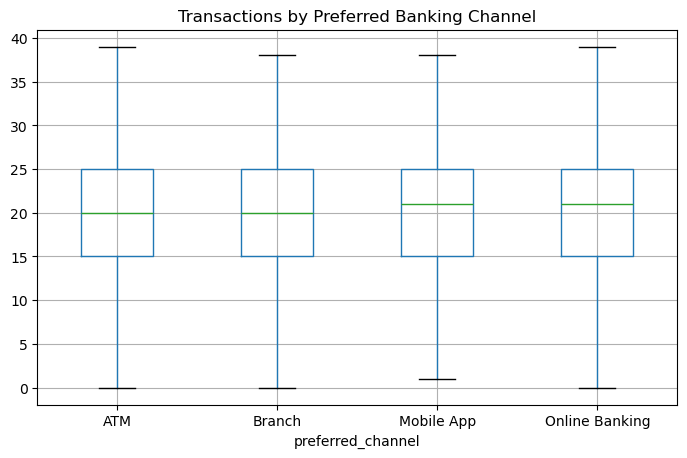

In [50]:
merged.boxplot(column="monthly_transactions", by="preferred_channel", figsize=(8,5))
plt.title("Transactions by Preferred Banking Channel")
plt.suptitle("")
plt.show()

In [ ]:
Ans: Customers using the Mobile App perform the highest number of monthly transactions.

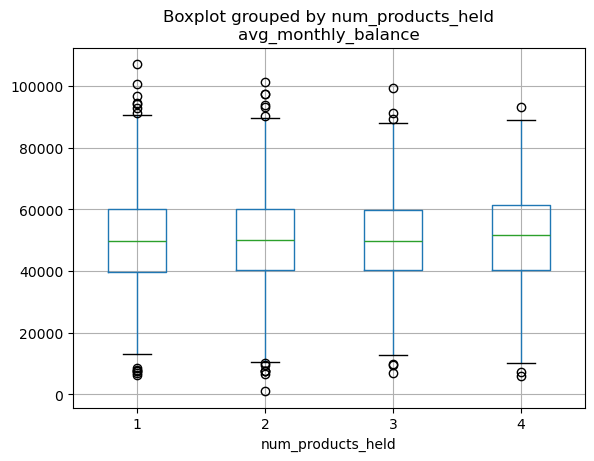

In [52]:
customers.boxplot(column="avg_monthly_balance", by="num_products_held")
plt.show()

In [ ]:
Ans:Customers with more banking products tend to maintain higher balances.

Multivariate Relationships - Correlations

In [53]:
merged=customers.merge(transactions,on="customer_id")

In [54]:
numeric_data=merged.select_dtypes(include=["int64","float64"])

In [55]:
corr=numeric_data.corr()
print(corr)

                               age  monthly_transactions_avg  \
age                       1.000000                 -0.025675   
monthly_transactions_avg -0.025675                  1.000000   
avg_monthly_balance       0.025602                  0.002970   
num_products_held         0.019455                  0.019402   
digital_adoption_score   -0.025821                  0.035062   
credit_card_issued       -0.008274                  0.033584   
loan_taken               -0.019969                 -0.014356   
monthly_transactions     -0.049086                 -0.007478   

                          avg_monthly_balance  num_products_held  \
age                                  0.025602           0.019455   
monthly_transactions_avg             0.002970           0.019402   
avg_monthly_balance                  1.000000           0.079458   
num_products_held                    0.079458           1.000000   
digital_adoption_score               0.027292           0.061850   
credit_card_iss

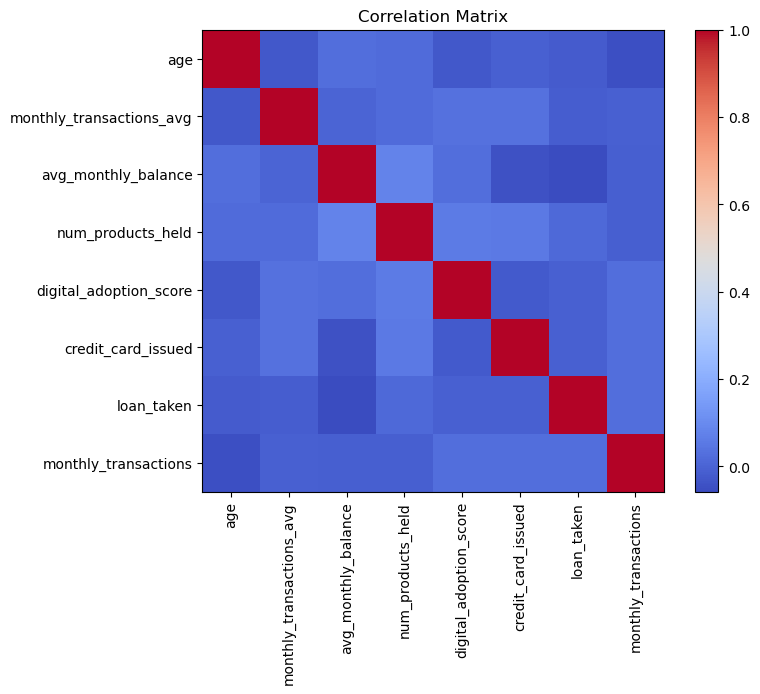

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
Ans:Digital adoption score shows a strong positive correlation with monthly transaction frequency.
    High balance customers represent a premium customer segment and should be retained through targeted offers.

In [ ]:
merged_df = pd.merge(
    customers,
    transactions,
    on="customer_id",
    how="inner"
)

In [59]:
merged_df.to_csv(
    r"C:\Users\admin\Downloads\Retail_Banking_Project\merged_retail_banking.csv",
    index=False
)

Encoding & Normalization


In [13]:
from sklearn.preprocessing  import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [7]:
customers = pd.read_csv(r"C:\Users\admin\Downloads\retail_banking_customers.csv")
transactions = pd.read_csv(r"C:\Users\admin\Downloads\retail_banking_transactions.csv")

In [8]:
merged=customers.merge(transactions,on="customer_id")

In [33]:
import os
print(os.getcwd())

C:\Users\admin


In [34]:
print(os.listdir())

['.anaconda', '.composio', '.conda', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.mamba', '.matplotlib', '.mcp-auth', '.mem0', '.spss', '.vscode', '2 May Deep learning.ipynb', '25 april Time Series.ipynb', '3 may pneunomonia detection using X-ray Images.ipynb', '3D Objects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'merged_retail_banking.csv', 'Microsoft', 'MicrosoftEdgeBackups', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{02d4803d-1598-11ed-8a21-eafcf4bc9da1}.TM.blf', 'NTUSER.DAT{02d4803d-1598-11ed-8a21-eafcf4bc9da1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{02d4803d-1598-11ed-8a21-eafcf4bc9da1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'Practice File Imarticus.ipynb', 'PrintHood', 'Python Day 4-iscale.ipynb', 'Python practise.ipynb', 'Recent'

In [39]:
import os

print(os.path.exists(r"C:\Users\admin\Downloads\Feature Engineering, Pre-processing & Splitting By Vedanti Madane.xlsx"))

False


In [48]:
import os

folder = r"C:\Users\admin\Downloads\Retail_Banking_Project"

print(os.listdir(folder))

['Feature Engineering, Pre-processing & Splitting By Vedanti Madane.xlsx', 'merged_retail_banking.csv', 'New Microsoft Excel Worksheet.xlsx', 'Retail_Banking EDA By Vedanti Madane.xlsx', 'Retail_Banking_Customers.xlsx', 'Retail_Banking_Transactions.xlsx', '~$Feature Engineering, Pre-processing & Splitting By Vedanti Madane.xlsx']


In [1]:
import pandas as pd

file_path = r"C:\Users\admin\Downloads\Retail Banking Project\Feature Engineering, Pre-processing & Splitting By Vedanti Madane.xlsx"

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\admin\\Downloads\\Retail Banking Project\\Feature Engineering, Pre-processing & Splitting By Vedanti Madane.xlsx'

In [17]:
#Drop customer id
df=df.drop("customer_id",axis=1)

In [2]:
#One Hot Encoding
categorical_columns=["region",
                     "preferred_channel",
                     "Age_group",
                     "Balance_Category",
                     "Month_Name"
]
df = pd.get_dummies(df,columns=categorical_columns)


#Scale Numerical Feature
scale_columns=["Age",
               "monthly_transactions_avg",
               "avg_monthly_balance",
               "num_products_held",
               "digital_adoption_score",
               "monthly_transactions"
]
scaler=StandardScaler()

df[scale_columns]=scaler.fit_transform(df[scale_columns])

print(df(head))


NameError: name 'df' is not defined

In [29]:
print(df.columns.tolist())

['customer_id', 'month', 'age', 'region', 'avg_monthly_balance']
